In [12]:
import pandas as pd
from statsbombpy import sb
import warnings

warnings.filterwarnings('ignore')

# Parametry
COMPETITION_ID = 43
SEASON_ID = 106

# Pobierz mecze
matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
match_ids = list(matches['match_id'])
print(f"Znaleziono {len(match_ids)} meczów")

goal_possessions = []

for idx, match_id in enumerate(match_ids):
    try:
        print(f"Przetwarzanie meczu {idx+1}/{len(match_ids)}", end='\r')
        
        events = sb.events(match_id=match_id)
        
        # Znajdź gole (Shot + outcome = Goal)
        goals = events[(events['type'] == 'Shot') & 
                      (events['shot_outcome'] == 'Goal')]
        
        # Dla każdego gola pobierz całe posiadanie
        for _, goal in goals.iterrows():
            possession_id = goal['possession']
            possession_events = events[events['possession'] == possession_id]
            goal_possessions.append(possession_events)
            
    except Exception as e:
        print(f"\nBłąd w meczu {match_id}: {str(e)}")
        continue

# Połącz wszystkie posiadania
df_goal_possessions = pd.concat(goal_possessions, ignore_index=True)

# Zachowaj tylko wybrane kolumny
columns_to_keep = [
    'match_id', 'possession', 'team', 'possession_team', 'index',
    'type', 'location', 'pass_end_location', 'carry_end_location',
    'shot_outcome', 'shot_end_location', 'player', 'minute', 'second'
]

df_goal_possessions = df_goal_possessions[columns_to_keep]

print(f"\n\nPobrano {len(df_goal_possessions)} zdarzeń z {len(goal_possessions)} posiadań zakończonych golem")

Znaleziono 64 meczów
Przetwarzanie meczu 64/64

Pobrano 4660 zdarzeń z 195 posiadań zakończonych golem


In [13]:
df_goal_possessions = df_goal_possessions[
    df_goal_possessions['type'].isin(['Pass', 'Carry', 'Shot'])
]

In [14]:
df_goal_possessions.head()

,match_id,possession,team,possession_team,index,type,location,pass_end_location,carry_end_location,shot_outcome,shot_end_location,player,minute,second
0,3857256,44,Switzerland,Switzerland,663,Pass,"[29.7, 74.2]","[22.9, 29.1]",NaN,NaN,NaN,Silvan Widmer,18,53
1,3857256,44,Switzerland,Switzerland,665,Pass,"[23.1, 29.7]","[46.3, 13.4]",NaN,NaN,NaN,Manuel Obafemi Akanji,18,55
2,3857256,44,Switzerland,Switzerland,668,Pass,"[46.3, 14.0]","[66.2, 5.6]",NaN,NaN,NaN,Ricardo Iván Rodríguez Araya,18,59
3,3857256,44,Switzerland,Switzerland,671,Pass,"[66.2, 5.6]","[89.1, 11.8]",NaN,NaN,NaN,Ruben Vargas,19,1
4,3857256,44,Switzerland,Switzerland,674,Pass,"[116.4, 27.5]","[113.2, 42.7]",NaN,NaN,NaN,Ricardo Iván Rodríguez Araya,19,8


In [15]:
def get_xy(loc):
    return (loc[0], loc[1]) if isinstance(loc, list) and len(loc) >= 2 else (None, None)

# start location
df_goal_possessions[['x', 'y']] = df_goal_possessions['location'].apply(
    lambda loc: pd.Series(get_xy(loc))
)

# wybór właściwej kolumny end_location zależnie od typu akcji
end_loc = (
    df_goal_possessions['pass_end_location'].where(df_goal_possessions['type'] == 'Pass')
    .combine_first(df_goal_possessions['carry_end_location'].where(df_goal_possessions['type'] == 'Carry'))
    .combine_first(df_goal_possessions['shot_end_location'].where(df_goal_possessions['type'] == 'Shot'))
)

# end location (dla Shot bierzemy tylko 2 pierwsze wartości — get_xy to gwarantuje)
df_goal_possessions[['x_end', 'y_end']] = end_loc.apply(
    lambda loc: pd.Series(get_xy(loc))
)

df_goal_possessions.drop(
    columns=['location', 'pass_end_location', 'carry_end_location', 'shot_end_location'],
    inplace=True
)


In [16]:
df_goal_possessions.head()

,match_id,possession,team,possession_team,index,type,shot_outcome,player,minute,second,x,y,x_end,y_end
0,3857256,44,Switzerland,Switzerland,663,Pass,NaN,Silvan Widmer,18,53,29.7,74.2,22.9,29.1
1,3857256,44,Switzerland,Switzerland,665,Pass,NaN,Manuel Obafemi Akanji,18,55,23.1,29.7,46.3,13.4
2,3857256,44,Switzerland,Switzerland,668,Pass,NaN,Ricardo Iván Rodríguez Araya,18,59,46.3,14.0,66.2,5.6
3,3857256,44,Switzerland,Switzerland,671,Pass,NaN,Ruben Vargas,19,1,66.2,5.6,89.1,11.8
4,3857256,44,Switzerland,Switzerland,674,Pass,NaN,Ricardo Iván Rodríguez Araya,19,8,116.4,27.5,113.2,42.7


In [17]:
# Normalizacja kierunku - jeśli possession_team != team, odwróć współrzędne
mask = df_goal_possessions['possession_team'] != df_goal_possessions['team']

df_goal_possessions.loc[mask, 'x'] = df_goal_possessions.loc[mask, 'x'].apply(lambda x: 120 - x if pd.notna(x) else None)
df_goal_possessions.loc[mask, 'y'] = df_goal_possessions.loc[mask, 'y'].apply(lambda y: 80 - y if pd.notna(y) else None)
df_goal_possessions.loc[mask, 'x_end'] = df_goal_possessions.loc[mask, 'x_end'].apply(lambda x: 120 - x if pd.notna(x) else None)
df_goal_possessions.loc[mask, 'y_end'] = df_goal_possessions.loc[mask, 'y_end'].apply(lambda y: 80 - y if pd.notna(y) else None)

In [18]:
df_goal_possessions[df_goal_possessions['team']=='Brazil']['player'].unique()

array(['Thiago Emiliano da Silva', 'Marcos Aoás Corrêa',
       'Alex Sandro Lobo Silva', 'Neymar da Silva Santos Junior',
       'Carlos Henrique Casimiro', 'Danilo Luiz da Silva',
       'Raphael Dias Belloli', 'Vinícius José Paixão de Oliveira Júnior',
       'Richarlison de Andrade', 'Bruno Guimarães Rodriguez Moura',
       'Rodrygo Silva de Goes', 'Éder Gabriel Militão',
       'Antony Matheus dos Santos', 'Lucas Tolentino Coelho de Lima',
       'Pedro Guilherme Abreu dos Santos', 'Frederico Rodrigues Santos'],
      dtype=object)

In [42]:
df_goals = df_goal_possessions[(df_goal_possessions['type']=='Shot')&(df_goal_possessions['shot_outcome']=='Goal')]

In [77]:
df_goal_possessions[
    (df_goal_possessions['match_id'] == 3857293) &
    (df_goal_possessions['possession'] == 57)
].sort_values('index')

,match_id,possession,team,possession_team,index,type,shot_outcome,player,minute,second,x,y,x_end,y_end
2745,3857293,57,Uruguay,Uruguay,921,Pass,NaN,Rodrigo Bentancur Colmán,30,44,75.4,18.1,73.6,33.1
2746,3857293,57,Uruguay,Uruguay,923,Pass,NaN,Federico Santiago Valverde Dipetta,30,45,73.4,35.2,75.3,18.4
2765,3857293,57,Uruguay,Uruguay,925,Carry,NaN,Rodrigo Bentancur Colmán,30,46,75.3,18.4,75.3,18.4
2747,3857293,57,Uruguay,Uruguay,926,Pass,NaN,Rodrigo Bentancur Colmán,30,46,75.3,18.4,75.0,5.7
2748,3857293,57,Uruguay,Uruguay,928,Pass,NaN,Mathías Olivera Miramontes,30,47,77.3,5.4,49.4,22.6
2766,3857293,57,Uruguay,Uruguay,930,Carry,NaN,Sebastián Coates Nión,30,49,49.4,22.6,44.7,21.0
2749,3857293,57,Uruguay,Uruguay,931,Pass,NaN,Sebastián Coates Nión,30,51,44.7,21.0,50.8,51.6
2767,3857293,57,Uruguay,Uruguay,933,Carry,NaN,José María Giménez de Vargas,30,52,50.8,51.6,52.0,50.4
2750,3857293,57,Uruguay,Uruguay,934,Pass,NaN,José María Giménez de Vargas,30,53,52.0,50.4,60.0,50.9
2768,3857293,57,Uruguay,Uruguay,936,Carry,NaN,Federico Santiago Valverde Dipetta,30,54,60.0,50.9,66.2,57.0


In [35]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

def plot_possession(df, match_id, possession_id, legend_pos=(0.04, 0.95)):
    """
    Wizualizacja przebiegu akcji na boisku.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame z danymi posiadań
    match_id : int
        ID meczu
    possession_id : int
        ID posiadania
    legend_pos : tuple
        Pozycja legendy (x, y) w układzie osi, domyślnie (0.02, 0.88)
    """
     # Filtruj dane
    possession = df[(df['match_id'] == match_id) & 
                    (df['possession'] == possession_id)].sort_values('index')
    
    # Stwórz boisko
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
    fig, ax = pitch.draw(figsize=(12, 8))
    
    # Kolory akcji
    colors = {'Pass': 'blue', 'Carry': 'lightblue', 'Shot': 'red'}
    
    # Zmienna do śledzenia poprzedniego zawodnika
    prev_player = None
    
    # Rysuj strzałki dla każdej akcji
    for _, event in possession.iterrows():
        if pd.notna(event['x']) and pd.notna(event['x_end']):
            color = colors.get(event['type'], 'gray')
            
            if event['type'] == 'Carry':
                # Dla Carry: przerywana linia + strzałka
                pitch.lines(event['x'], event['y'], 
                           event['x_end'], event['y_end'],
                           ax=ax, color=color, lw=2, linestyle='--')
                pitch.arrows(event['x'], event['y'], 
                           event['x_end'], event['y_end'],
                           ax=ax, color=color, width=2, headwidth=4, headlength=4,
                           alpha=0)  # Niewidoczna linia, tylko strzałka
            else:
                # Dla Pass i Shot: ciągła linia
                pitch.arrows(event['x'], event['y'], 
                           event['x_end'], event['y_end'],
                           ax=ax, color=color, width=2, headwidth=4, headlength=4)
            
            # Dodaj nazwisko zawodnika tylko jeśli różni się od poprzedniego
            if pd.notna(event['player']) and event['player'] != prev_player:
                ax.text(event['x'], event['y'], event['player'], 
                       fontsize=8, color='white', ha='center', va='bottom',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.5))
                prev_player = event['player']
            elif event['player'] == prev_player:
                prev_player = event['player']
            else:
                prev_player = None
    
    # Legenda
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='blue', label='Pass'),
        Patch(facecolor='lightblue', label='Carry'),
        Patch(facecolor='red', label='Shot')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=14, 
             facecolor='#22312b', edgecolor='white', labelcolor='white',
             bbox_to_anchor=legend_pos, framealpha=0.8)
    
    # Tytuł
    plt.title(f"Match {match_id} - Possession {possession_id}", 
              color='white', fontsize=14)
    plt.tight_layout()
    plt.show()

# Przykład użycia:
# plot_possession(df_goal_possessions, match_id=3788741, possession_id=45, legend_pos=(0.02, 0.88))

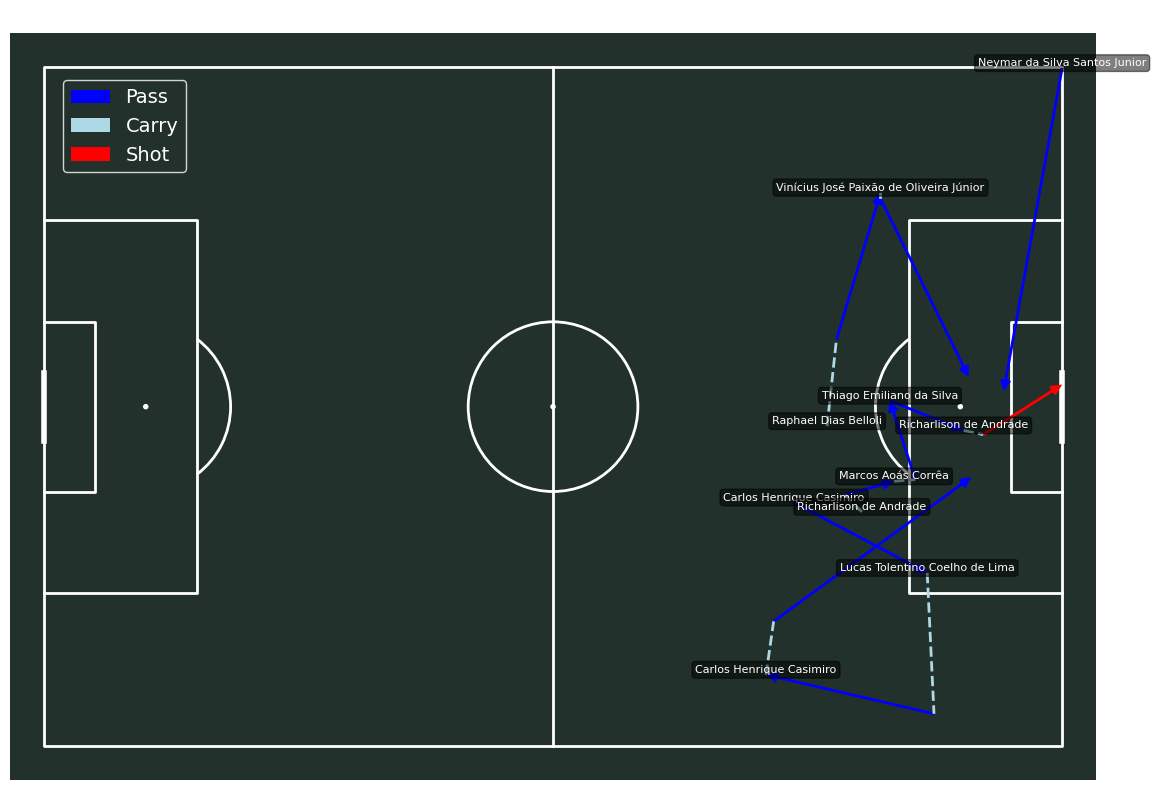

In [36]:
plot_possession(df_goal_possessions, match_id=3869253, possession_id=46)

In [44]:
def plot_possession_save(df, match_id, possession_id, legend_pos=(0.04, 0.95), save_path=None):
    """
    Wizualizacja przebiegu akcji na boisku z opcją zapisu.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame z danymi posiadań
    match_id : int
        ID meczu
    possession_id : int
        ID posiadania
    legend_pos : tuple
        Pozycja legendy (x, y) w układzie osi, domyślnie (0.02, 0.88)
    save_path : str, optional
        Ścieżka do zapisu pliku. Jeśli None, wykres zostanie wyświetlony.
    """
    # Filtruj dane
    possession = df[(df['match_id'] == match_id) & 
                    (df['possession'] == possession_id)].sort_values('index')
    
    # Stwórz boisko
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
    fig, ax = pitch.draw(figsize=(12, 8))
    
    # Kolory akcji
    colors = {'Pass': 'blue', 'Carry': 'lightblue', 'Shot': 'red'}
    
    # Zmienna do śledzenia poprzedniego zawodnika
    prev_player = None
    
    # Rysuj strzałki dla każdej akcji
    for _, event in possession.iterrows():
        if pd.notna(event['x']) and pd.notna(event['x_end']):
            color = colors.get(event['type'], 'gray')
            
            if event['type'] == 'Carry':
                # Dla Carry: przerywana linia + strzałka
                pitch.lines(event['x'], event['y'], 
                           event['x_end'], event['y_end'],
                           ax=ax, color=color, lw=2, linestyle='--')
                pitch.arrows(event['x'], event['y'], 
                           event['x_end'], event['y_end'],
                           ax=ax, color=color, width=2, headwidth=4, headlength=4,
                           alpha=0)
            else:
                # Dla Pass i Shot: ciągła linia
                pitch.arrows(event['x'], event['y'], 
                           event['x_end'], event['y_end'],
                           ax=ax, color=color, width=2, headwidth=4, headlength=4)
            
            # Dodaj nazwisko zawodnika tylko jeśli różni się od poprzedniego
            if pd.notna(event['player']) and event['player'] != prev_player:
                ax.text(event['x'], event['y'], event['player'], 
                       fontsize=8, color='white', ha='center', va='bottom',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.5))
                prev_player = event['player']
            elif event['player'] == prev_player:
                prev_player = event['player']
            else:
                prev_player = None
    
    # Legenda
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='blue', label='Pass'),
        Patch(facecolor='lightblue', label='Carry'),
        Patch(facecolor='red', label='Shot')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=14, 
             facecolor='#22312b', edgecolor='white', labelcolor='white',
             bbox_to_anchor=legend_pos, framealpha=0.8)
    
    # Tytuł
    plt.title(f"Match {match_id} - Possession {possession_id}", 
              color='white', fontsize=14)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#22312b')
        plt.close()
    else:
        plt.show()

In [45]:
import os

# Stwórz folder jeśli nie istnieje
output_dir = 'Goal_actions'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Utworzono folder: {output_dir}")

# Wyciągnij unikalne pary (match_id, possession)
df_goals = df_goal_possessions[(df_goal_possessions['type']=='Shot') & 
                                (df_goal_possessions['shot_outcome']=='Goal')]

unique_possessions = df_goals[['match_id', 'possession']].drop_duplicates()

print(f"Znaleziono {len(unique_possessions)} akcji bramkowych do wizualizacji")

# Iteruj i zapisuj wykresy
for idx, (_, row) in enumerate(unique_possessions.iterrows(), 1):
    match_id = row['match_id']
    possession_id = row['possession']
    
    print(f"Generowanie wykresu {idx}/{len(unique_possessions)}: match={match_id}, possession={possession_id}", end='\r')
    
    # Generuj wykres (modyfikacja funkcji aby zapisywała zamiast pokazywać)
    plot_possession_save(df_goal_possessions, match_id, possession_id, 
                         save_path=os.path.join(output_dir, f"goal_m{match_id}_p{possession_id}.png"))

print(f"\n\nZapisano {len(unique_possessions)} wykresów w folderze '{output_dir}'")

Utworzono folder: Goal_actions
Znaleziono 195 akcji bramkowych do wizualizacji
Generowanie wykresu 195/195: match=3857255, possession=719

Zapisano 195 wykresów w folderze 'Goal_actions'


In [75]:
sample = df_goal_possessions[(df_goal_possessions['match_id']==3857293)&(df_goal_possessions['possession']==57)]
sample = sample.sort_values('index')

In [76]:
sample.to_csv("akcja_do_skorowania.csv", index=False)

In [55]:
"""
Convert DataFrame sample to model tokens
"""

import torch
import pandas as pd

def df_to_tokens(df_sample, type_vocab):
    """
    Convert DataFrame sample (single possession) to model input tokens
    
    Args:
        df_sample: DataFrame with columns: index, type, x, y, x_end, y_end, player, minute, second
        type_vocab: Dict mapping type names to IDs 
                   {'Pass': 0, 'Shot': 1, 'GOAL': 2, 'NO_GOAL': 3, '<pad>': 4}
    
    Returns:
        Dict with:
            - input_types: tensor [seq_len] - type IDs
            - input_positions: tensor [seq_len, 4] - [x, y, end_x, end_y]
            - input_start_mask: tensor [seq_len] - True where x,y available
    
    Notes:
        - Sorts events by 'index' column before processing
        - Filters out 'Carry' events (not in vocabulary)
        - Normalizes coordinates to [0,1]: x/120, y/80
    """
    # Sort by index column
    df_sorted = df_sample.sort_values('index').reset_index(drop=True)
    
    # Filter out Carry events (not in vocab)
    df_filtered = df_sorted[df_sorted['type'] != 'Carry'].reset_index(drop=True)
    
    events = []
    
    for idx, row in df_filtered.iterrows():
        event = {
            'type': row['type'],
            'x': row['x'] / 120.0 if pd.notna(row['x']) else None,  # Normalize to [0,1]
            'y': row['y'] / 80.0 if pd.notna(row['y']) else None,   # Normalize to [0,1]
            'end_x': row['x_end'] / 120.0 if pd.notna(row['x_end']) else None,
            'end_y': row['y_end'] / 80.0 if pd.notna(row['y_end']) else None,
        }
        events.append(event)
    
    # Convert to tokens
    types = []
    positions = []
    start_masks = []
    
    for e in events:
        # Type ID
        types.append(type_vocab[e['type']])
        
        # Position [start_x, start_y, end_x, end_y]
        pos = [
            e['x'] if e['x'] is not None else 0.0,
            e['y'] if e['y'] is not None else 0.0,
            e['end_x'] if e['end_x'] is not None else 0.0,
            e['end_y'] if e['end_y'] is not None else 0.0
        ]
        positions.append(pos)
        
        # Start mask (True if x,y available)
        start_masks.append(e['x'] is not None)
    
    return {
        'input_types': torch.tensor(types, dtype=torch.long),
        'input_positions': torch.tensor(positions, dtype=torch.float32),
        'input_start_mask': torch.tensor(start_masks, dtype=torch.bool)
    }


def view_tokens(tokens, df_sample=None, type_vocab=None):
    """
    Pretty print tokens for inspection
    
    Args:
        tokens: Dict from df_to_tokens
        df_sample: Optional original DataFrame for comparison
        type_vocab: Optional vocab dict to show type names
    """
    # Reverse vocab for type names
    if type_vocab:
        id_to_type = {v: k for k, v in type_vocab.items()}
    else:
        id_to_type = None
    
    print("="*80)
    print("TOKENS INSPECTION")
    print("="*80)
    print(f"Sequence length: {len(tokens['input_types'])}")
    print()
    
    for i in range(len(tokens['input_types'])):
        type_id = tokens['input_types'][i].item()
        pos = tokens['input_positions'][i]
        mask = tokens['input_start_mask'][i].item()
        
        type_name = id_to_type[type_id] if id_to_type else f"ID={type_id}"
        
        print(f"Token {i:2d}:")
        print(f"  Type:      {type_name:10s} (ID={type_id})")
        print(f"  Position:  [{pos[0]:.3f}, {pos[1]:.3f}, {pos[2]:.3f}, {pos[3]:.3f}]")
        print(f"             (start_x, start_y, end_x, end_y)")
        print(f"  Start mask: {mask}")
        
        # If DataFrame provided, show original values
        if df_sample is not None:
            row = df_sample.iloc[i]
            print(f"  Original:  x={row['x']:.1f}, y={row['y']:.1f}, "
                  f"end_x={row['x_end']:.1f}, end_y={row['y_end']:.1f}")
            if 'player' in row:
                print(f"  Player:    {row['player']}")
        print()


def view_tokens_compact(tokens, df_sample=None, type_vocab=None):
    """
    Compact table view of tokens
    """
    # Reverse vocab
    if type_vocab:
        id_to_type = {v: k for k, v in type_vocab.items()}
    else:
        id_to_type = None
    
    print("="*100)
    print(f"{'Idx':>3} | {'Type':>8} | {'TypeID':>6} | {'Start X':>7} | {'Start Y':>7} | "
          f"{'End X':>7} | {'End Y':>7} | {'Mask':>5}")
    print("-"*100)
    
    for i in range(len(tokens['input_types'])):
        type_id = tokens['input_types'][i].item()
        pos = tokens['input_positions'][i]
        mask = tokens['input_start_mask'][i].item()
        
        type_name = id_to_type[type_id] if id_to_type else f"{type_id}"
        
        print(f"{i:3d} | {type_name:>8s} | {type_id:6d} | "
              f"{pos[0]:7.3f} | {pos[1]:7.3f} | "
              f"{pos[2]:7.3f} | {pos[3]:7.3f} | "
              f"{'True' if mask else 'False':>5s}")
    
    print("="*100)
    
    # If DataFrame provided, show players
    if df_sample is not None and 'player' in df_sample.columns:
        print("\nPlayers:")
        for i, player in enumerate(df_sample['player']):
            print(f"  {i:2d}: {player}")

In [57]:
# ============================================
# EXAMPLE USAGE
# ============================================

# Your sample DataFrame
sample = df_goal_possessions[
    (df_goal_possessions['match_id']==3857293) & 
    (df_goal_possessions['possession']==57)
]

# Type vocab (load from file or define)
type_vocab = {
    'Pass': 0,
    'Shot': 1, 
    'GOAL': 2,
    'NO_GOAL': 3,
    '<pad>': 4
}

# Convert to tokens
tokens = df_to_tokens(sample, type_vocab)

print("Types:", tokens['input_types'])
print("Positions shape:", tokens['input_positions'].shape)
print("Start mask:", tokens['input_start_mask'])

# Output:
# Types: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2])
# Positions shape: torch.Size([17, 4])
# Start mask: tensor([True, True, True, ..., True])

# Now you can pass to model:
# model(tokens['input_types'].unsqueeze(0).to(device),
#       tokens['input_positions'].unsqueeze(0).to(device),
#       tokens['input_start_mask'].unsqueeze(0).to(device))

Types: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
Positions shape: torch.Size([11, 4])
Start mask: tensor([True, True, True, True, True, True, True, True, True, True, True])


In [59]:
# Najszybsza metoda
tokens = df_to_tokens(sample, type_vocab)
view_tokens(tokens, type_vocab=type_vocab)

TOKENS INSPECTION
Sequence length: 11

Token  0:
  Type:      Pass       (ID=0)
  Position:  [0.628, 0.226, 0.613, 0.414]
             (start_x, start_y, end_x, end_y)
  Start mask: True

Token  1:
  Type:      Pass       (ID=0)
  Position:  [0.612, 0.440, 0.627, 0.230]
             (start_x, start_y, end_x, end_y)
  Start mask: True

Token  2:
  Type:      Pass       (ID=0)
  Position:  [0.627, 0.230, 0.625, 0.071]
             (start_x, start_y, end_x, end_y)
  Start mask: True

Token  3:
  Type:      Pass       (ID=0)
  Position:  [0.644, 0.068, 0.412, 0.282]
             (start_x, start_y, end_x, end_y)
  Start mask: True

Token  4:
  Type:      Pass       (ID=0)
  Position:  [0.373, 0.262, 0.423, 0.645]
             (start_x, start_y, end_x, end_y)
  Start mask: True

Token  5:
  Type:      Pass       (ID=0)
  Position:  [0.433, 0.630, 0.500, 0.636]
             (start_x, start_y, end_x, end_y)
  Start mask: True

Token  6:
  Type:      Pass       (ID=0)
  Position:  [0.552, 0.712